<a href="https://colab.research.google.com/github/PadmapriyaaMA/pneumonia_detection/blob/main/case_study_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

# Extract dataset
zip_path = "/content/pnuemonia-arch.zip"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# Verify image counts
dataset_path = "/content/Pnuemonia"
negative_path = os.path.join(dataset_path, "Negative")
positive_path = os.path.join(dataset_path, "Positive")

negative_images = [f for f in os.listdir(negative_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]
positive_images = [f for f in os.listdir(positive_path) if f.lower().endswith((".jpg", ".jpeg", ".png"))]

print("Negative (Normal) images :", len(negative_images))
print("Positive (Pneumonia) images :", len(positive_images))

Negative (Normal) images : 500
Positive (Pneumonia) images : 500


In [ ]:
import tensorflow as tf

dataset_path = "/content/Pnuemonia"
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.


Found 1000 files belonging to 2 classes.
Using 800 files for training.
Found 1000 files belonging to 2 classes.
Using 200 files for validation.
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
=== Phase 1: Feature Extraction ===
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 113s 4s/step - accuracy: 0.5163 - loss: 0.8245 - val_accuracy: 0.6050 - val_loss: 0.6674
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 99s 4s/step - accuracy: 0.5450 - loss: 0.6940 - val_accuracy: 0.5750 - val_loss: 0.6690
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 101s 4s/step - accuracy: 0.5487 - loss: 0.6857 - val_accuracy: 0.5950 - val_loss: 0.6850
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 148s 4s/step - accuracy: 0.5863 - loss: 0.6746 - val_accuracy: 0.5650 - val_loss: 0.6908
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.6125 - loss: 0.6635 - val_accuracy: 0.6250 - val_loss: 0.6620
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 141s 4s/step - accuracy: 0.6150 - loss: 0.6558 - val_accuracy: 0.6200 - val_loss: 0.6566
Epoch 7/

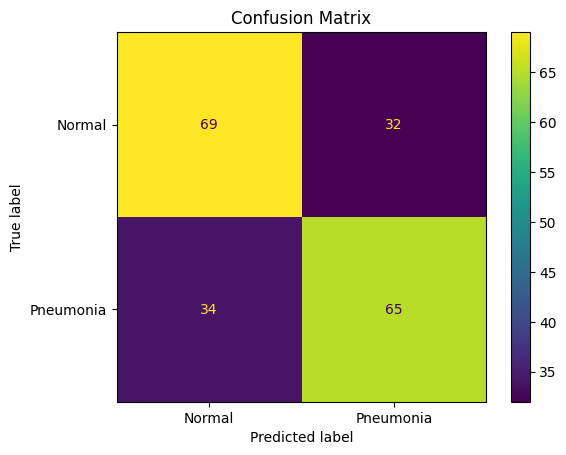

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Dataset Setup
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
dataset_path = "/content/Pnuemonia"

train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

# 2. Lightweight Data Augmentation
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
])

# 3. DenseNet121 Backbone
base_model = DenseNet121(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze backbone for initial stability

# 4. Model Construction
inputs = layers.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

# Phase 1: Train Classification Head
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("=== Phase 1: Feature Extraction ===")
model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10
)

# Phase 2: Unfreeze Top Dense Block for Medical Fine-Tuning
print("\n=== Phase 2: Fine-Tuning DenseNet ===")
base_model.trainable = True

# Freeze initial blocks, unfreeze last 30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=6,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)

# 5. Final Evaluation
print("\n=== FINAL EVALUATION ===")
loss, accuracy = model.evaluate(validation_dataset, verbose=0)
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Validation Loss: {loss:.4f}\n")

y_true, y_pred = [], []
for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)
    y_true.extend(labels.numpy().flatten())
    y_pred.extend((predictions.flatten() >= 0.5).astype(int))

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Normal", "Pneumonia"]))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Pneumonia"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()